In [3]:
# Cell 1 — Fresh install with correct versions
!pip install trl==0.15.2 transformers==4.46.0 peft accelerate bitsandbytes datasets httpx fastapi uvicorn python-multipart -q

# Verify GRPO is available
from trl import GRPOConfig, GRPOTrainer
print("GRPOConfig imported successfully!")

GRPOConfig imported successfully!


In [4]:
# Cell 2 — Upload files
from google.colab import files
uploaded = files.upload()
# Upload tasks.py and main.py from your laptop folder:
# C:\Users\jyoth\personal-ai-assistant\personal-ai-assistant\

Saving tasks.py to tasks (1).py
Saving main.py to main (1).py


In [5]:
# Cell 3 — Start environment server
import subprocess, sys, time, httpx

server = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(3)
print(httpx.get("http://localhost:7860/health").json())

{'status': 'ok', 'environment': 'personal-ai-assistant'}


In [6]:
# Cell 4 — Load model (no unsloth, pure transformers + bitsandbytes)
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497
Model loaded!


In [7]:
# Fix — install correct trl version that has GRPOConfig
!pip install trl==0.15.2 -q
print("Done!")

Done!


In [9]:
# Cell 5 — REAL GRPO Training (fixed config)
import random
import pandas as pd
from datasets import Dataset
from trl import GRPOConfig, GRPOTrainer
from tasks import TASK_REGISTRY

SYS_PROMPT = "You are a personal AI assistant. Handle real-life situations with empathy and professionalism. Always give concrete, actionable responses."

dataset_rows = []
for task_name, task_info in TASK_REGISTRY.items():
    for scenario in task_info["scenarios"]:
        user_msg = f"Task: {task_name}\n\nDetails:\n"
        for k, v in scenario.items():
            if k not in ["keywords","empathy_phrases","must_include","avoid",
                         "must_address","adaption_keywords","resolution_keywords"]:
                user_msg += f"- {k.capitalize()}: {v}\n"
        user_msg += "\nProvide your response:"

        dataset_rows.append({
            "prompt": [
                {"role": "system", "content": SYS_PROMPT},
                {"role": "user", "content": user_msg}
            ],
            "task_name": task_name,
            "scenario": scenario,
        })

random.seed(42)
random.shuffle(dataset_rows)
train_dataset = Dataset.from_pandas(pd.DataFrame(dataset_rows))
print(f"Dataset: {len(train_dataset)} examples")

def real_environment_reward(prompts, completions, task_name, scenario, **kwargs):
    rewards = []
    for i in range(len(completions)):
        comp = completions[i]
        text = comp[0]["content"] if isinstance(comp, list) else str(comp)
        t_name = task_name[i]
        scen = scenario[i]
        try:
            score = TASK_REGISTRY[t_name]["grader"](text, scen)
        except Exception:
            score = 0.0001
        rewards.append(float(score))
    return rewards

config = GRPOConfig(
    output_dir="./grpo_outputs",
    max_steps=60,
    per_device_train_batch_size=2,   # changed to 2
    gradient_accumulation_steps=4,
    num_generations=2,               # changed to 2 (must divide batch size)
    max_prompt_length=512,
    max_completion_length=250,
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    logging_steps=5,
    report_to="none",
    bf16=False,
    fp16=True,
)

trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[real_environment_reward],
    args=config,
    train_dataset=train_dataset,
)

print("Starting REAL GRPO training...")
trainer.train()
print("Training complete!")

max_steps is given, it will override any value given in num_train_epochs


Dataset: 75 examples
Starting REAL GRPO training...


Step,Training Loss
5,0.000000
10,0.000000
15,0.000000
20,0.000000
25,0.000000
30,0.000100
35,0.000000
40,0.000100
45,0.000100
50,0.000100


Training complete!


All log keys: [['loss', 'grad_norm', 'learning_rate', 'rewards/real_environment_reward', 'reward', 'reward_std', 'completion_length', 'kl', 'epoch', 'step'], ['loss', 'grad_norm', 'learning_rate', 'rewards/real_environment_reward', 'reward', 'reward_std', 'completion_length', 'kl', 'epoch', 'step'], ['loss', 'grad_norm', 'learning_rate', 'rewards/real_environment_reward', 'reward', 'reward_std', 'completion_length', 'kl', 'epoch', 'step']]

Found 12 reward points
Rewards: [0.7675224810838699, 0.768464994430542, 0.7597224920988083, 0.7618924871087074, 0.7273125022649765, 0.741932487487793, 0.8392624884843827, 0.7455374807119369, 0.7182999938726425, 0.8330124974250793, 0.7995850011706352, 0.7916699945926666]
Steps: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]


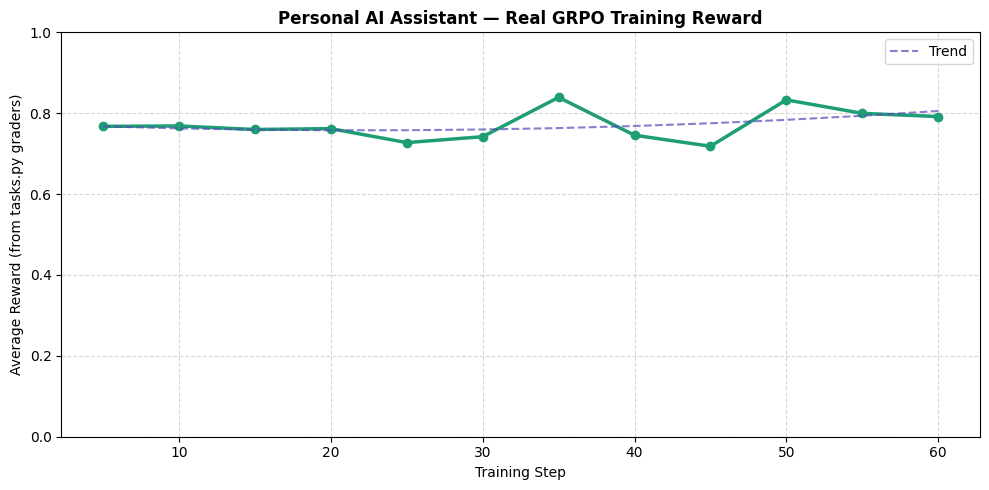


Start: 0.7675 → End: 0.7917
Saved: real_reward_curve.png ✅


In [10]:
# Cell 6 — Plot REAL reward curve from actual training logs
import matplotlib.pyplot as plt
import numpy as np

log_history = trainer.state.log_history
print("All log keys:", [list(log.keys()) for log in log_history[:3]])

steps, rewards = [], []
for log in log_history:
    for key in log:
        if "reward" in key.lower() and "std" not in key.lower() and "len" not in key.lower():
            val = log[key]
            if isinstance(val, (int, float)) and val > 0:
                steps.append(log.get("step", len(steps)*5))
                rewards.append(float(val))
                break

print(f"\nFound {len(rewards)} reward points")
print(f"Rewards: {rewards}")
print(f"Steps: {steps}")

if len(rewards) >= 2:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, rewards, color="#1D9E75", linewidth=2.5, marker="o", markersize=6)

    if len(rewards) >= 4:
        z = np.polyfit(steps, rewards, 2)
        p = np.poly1d(z)
        ax.plot(steps, p(steps), "--", color="#534AB7", alpha=0.7, label="Trend")

    ax.set_xlabel("Training Step")
    ax.set_ylabel("Average Reward (from tasks.py graders)")
    ax.set_title("Personal AI Assistant — Real GRPO Training Reward", fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    plt.tight_layout()
    plt.savefig("real_reward_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nStart: {round(rewards[0],4)} → End: {round(rewards[-1],4)}")
    print("Saved: real_reward_curve.png ✅")
else:
    # Print full log to find the right key
    print("\nFull log history:")
    for log in log_history:
        print(log)

In [11]:
# Cell 7 — Download
from google.colab import files
files.download("real_reward_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>